<a href="https://colab.research.google.com/github/alejolemos1/Evaluacion-de-proyectos-de-inversion-con-Python/blob/main/Evaluacion_de_proyectos_por_lotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install numpy-financial

In [14]:
import pandas as pd
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt

In [23]:
df = pd.DataFrame(pd.read_excel('proyectos.xlsx'))
df

,Proyecto,Año0,Año1,Año2,Año3,Año4,Año5
0,A,-70000,1000,25000,15000,40000,2000
1,B,-50000,2000,14000,14000,14000,14000
2,C,-20000,20000,-2000,2000,2000,2000
3,D,-40000,12000,3000,3000,3000,3000
4,E,-24000,5000,10000,12000,6000,6000
5,F,-20000,8000,10000,2000,12000,6000
6,G,-25000,7000,20000,20000,2000,2000
7,H,-35000,21000,12000,12000,20000,2000


In [16]:
def calc_payback(cashflows):
  acumulado = 0
  for i, f in enumerate(cashflows):
    acumulado += f
    if acumulado >=0:
      porcion_año = (f-acumulado)/f
      return porcion_año + i -1
  return "No recupera"

def calc_dpayback(cashflows):
  acumulado = 0
  for i, f in enumerate(cashflows):
    acumulado += f/(1+h_rate)**i
    if acumulado >=0:
      porcion_año = (f-acumulado)/f
      return porcion_año + i -1
  return "No recupera"

In [25]:
h_rate = pd.read_excel('proyectos.xlsx', sheet_name="Parámetros")['WACC'][0]
results = []
for _, row in df.iterrows():
  proyecto = row['Proyecto']
  flujos = row.iloc[1:].values.astype(float)
  van = npf.npv(h_rate, flujos)
  tir = npf.irr(flujos)
  tirm = npf.mirr(flujos, h_rate, h_rate)
  decisión = 'Invertir' if van >= 0 else 'Rechazar'
  pb = calc_payback(flujos)
  dpb = calc_dpayback(flujos)
  results.append([proyecto, round(van,2), round(tir,2), round(tirm,2), decisión, round(pb,2) if isinstance(pb, float) else pb, round(dpb,2) if isinstance(dpb,float) else dpb])
res = pd.DataFrame(results, columns=['Proyecto', 'VAN', 'TIR', 'TIRM', 'Decisión', "Payback", "Discounted Payback"]).sort_values('VAN', ascending=False)
res

,Proyecto,VAN,TIR,TIRM,Decisión,Payback,Discounted Payback
7,H,17926.15,0.32,0.19,Invertir,2.17,2.75
6,G,15526.73,0.36,0.21,Invertir,1.9,2.35
5,F,8961.51,0.27,0.18,Invertir,3.0,3.56
4,E,5649.30,0.19,0.15,Invertir,2.75,3.68
2,C,639.42,0.12,0.11,Invertir,1.0,4.68
1,B,-7838.08,0.04,0.06,Rechazar,4.43,No recupera
0,A,-8597.65,0.06,0.07,Rechazar,3.72,No recupera
3,D,-20445.82,-0.19,-0.05,Rechazar,No recupera,No recupera


Text(0, 0.5, 'VAN')

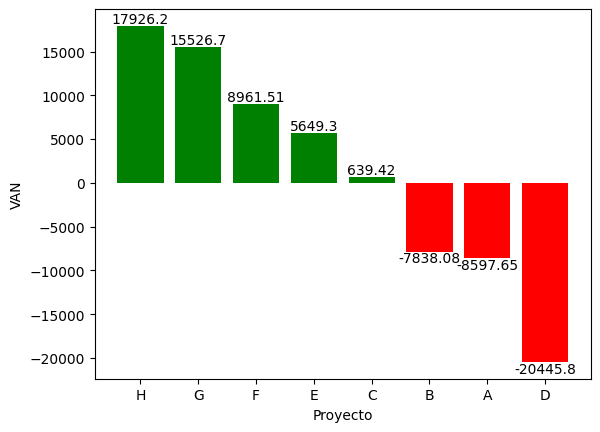

In [26]:
colors = ['green' if van >= 0 else 'red' for van in res['VAN']]
plt.bar_label(plt.bar(res['Proyecto'], res['VAN'], color=colors))
plt.xlabel('Proyecto')
plt.ylabel('VAN')